In [1]:
import pandas as pd
import numpy as np
import sys
from contextlib import redirect_stdout

from ml_pipeline.subpopulation import run_pipeline, run_model_error_analysis
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# FILTER TO MULTIPLE QUOTE CUSTOMERS
print("\n🎯 FILTERING TO MULTIPLE QUOTE CUSTOMERS")
print("="*80)

# Load data
df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])

# Count quotes per customer
quote_counts = df_quotes.groupby('numero_compte').size().reset_index(name='quote_count')

# Get customers with 2+ quotes
multi_quote_ids = quote_counts[quote_counts['quote_count'] >= 2]['numero_compte'].tolist()

# Filter data
df_quotes_multi = df_quotes[df_quotes['numero_compte'].isin(multi_quote_ids)].copy()

print(f"Original customers: {df_quotes['numero_compte'].nunique():,}")
print(f"Multiple quote customers (≥2): {len(multi_quote_ids):,}")
print(f"Quotes: {len(df_quotes_multi):,}")

# Save to file
df_quotes_multi.to_csv('cleaned_quote_data_multi.csv', index=False)
print(f"\n✅ Saved to cleaned_quote_data_multi.csv")


🎯 FILTERING TO MULTIPLE QUOTE CUSTOMERS
Original customers: 25,716
Multiple quote customers (≥2): 7,858
Quotes: 19,150

✅ Saved to cleaned_quote_data_multi.csv


In [3]:
df_quotes = pd.read_csv('cleaned_quote_data_multi.csv')


📊 Original quote data: 19,150 quotes from 7,858 customers

🏗️  BUILDING FEATURES FOR SUBPOPULATION CUSTOMERS
Creating OPTIMIZED customer features (mode: first_conversion)...
  Filtering post-first-purchase data...
  Customers: 7,858, Quotes: 18,095
  Calculating features...
  Calculating price trajectory (optimized)...
✓ Created 14 leakage-free features
→ 7,858 customers | 44.9% converters
⏱️  Execution time: 3.3 seconds
⚠️  3.3s (target was 3s)
CREATING FIRST CONVERSION PREDICTION FEATURES (LEAKAGE-FREE)
  Total customers: 7,858
⚡ Processing customers with corrected first-conversion logic...
  Processed 0/7,858 customers
  Processed 5,000/7,858 customers
✅ First-conversion features calculation complete

🔍 VALIDATION REPORT:
   Total customers: 7,858
   First converters: 3,528 (44.9%)
   Never converters: 4,330

📊 Distribution check:
   Converters with 0 historical quotes: 1,493
   Non-converters with 0 historical quotes: 0
   Avg historical quotes - Converters: 0.8
   Avg historical 

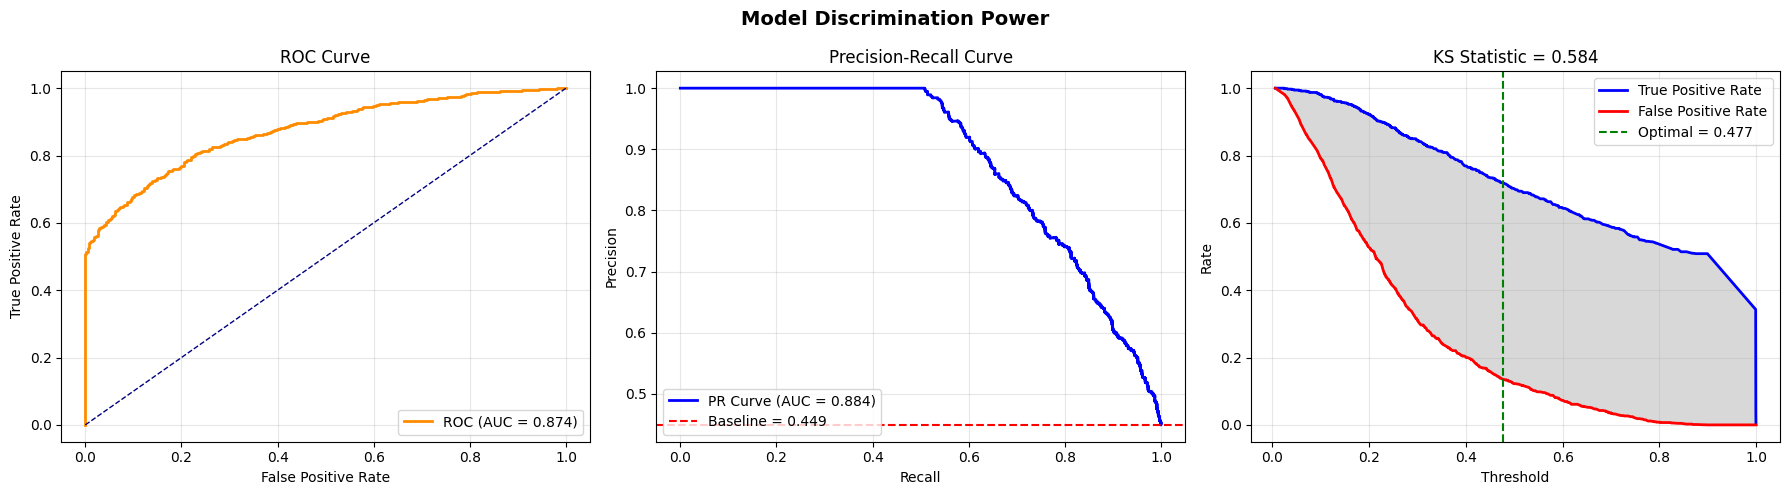

• ROC-AUC: 0.8737
• PR-AUC: 0.8839
• KS Statistic: 0.584 (EXCELLENT discrimination)
• Optimal Threshold: 0.477

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.999
Decile 10 mean prob: 0.051


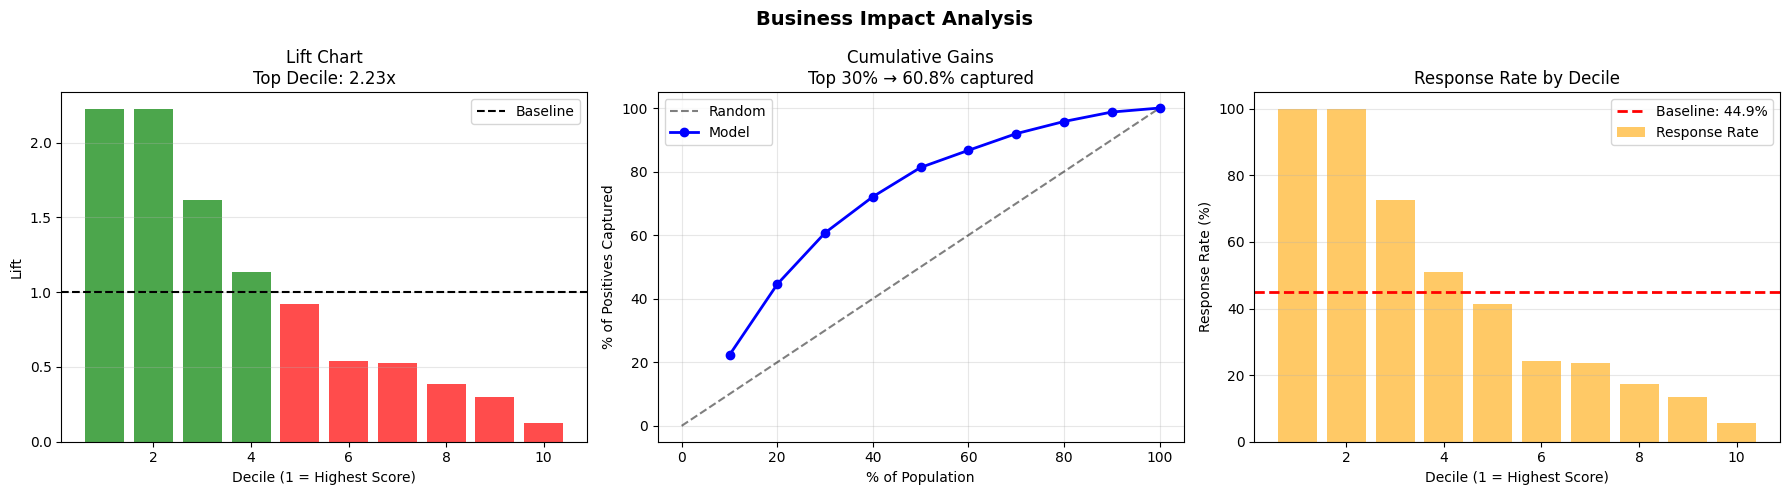

• Top Decile Lift: 0.13x
• Top 30% captures: 60.8% of positives
• Baseline response rate: 44.9%
• Top decile response: 100.0%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


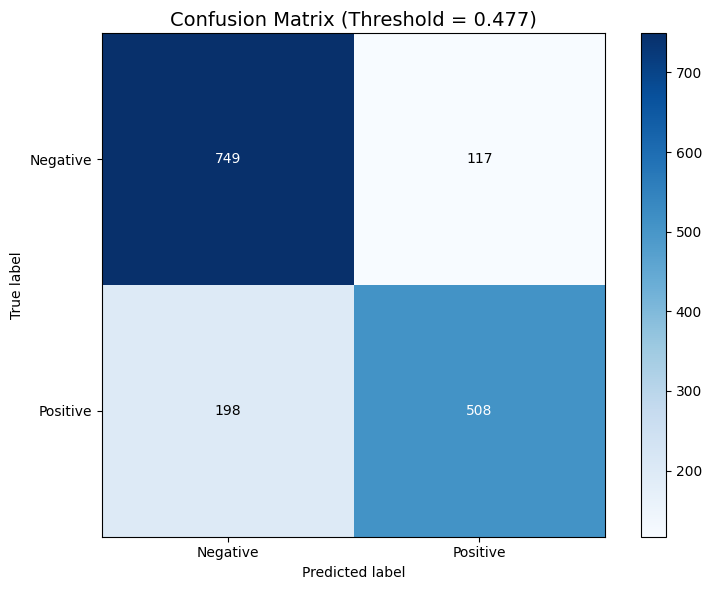

At threshold 0.477:
• Accuracy: 0.800
• Precision: 0.813
• Recall: 0.720
• F1-Score: 0.763
• True Positives: 508
• False Positives: 117
• True Negatives: 749
• False Negatives: 198

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.584 (EXCELLENT discrimination)

✅ BUSINESS VALUE:
   Efficiency: 0.13x better than random
   Coverage: Top 30% → 60.8% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.8737 (Excellent if >0.8)
   PR-AUC: 0.8839 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.477
   Precision at threshold: 0.813
   Recall at threshold: 0.720

🔍 FEATURE IMPORTANCE - SUBPOPULATION MODEL

Top 20 Features:
                         feature  importance
176      quote_consistency_score    0.190414
98       avg_days_between_quotes    0.083574
152              engagement_days    0.020548
178    decision_efficiency_score    0.014486
173          brand_loyalty_score    0.013359
177      quote_price_sensitivity    0.013305
248                  value_score  

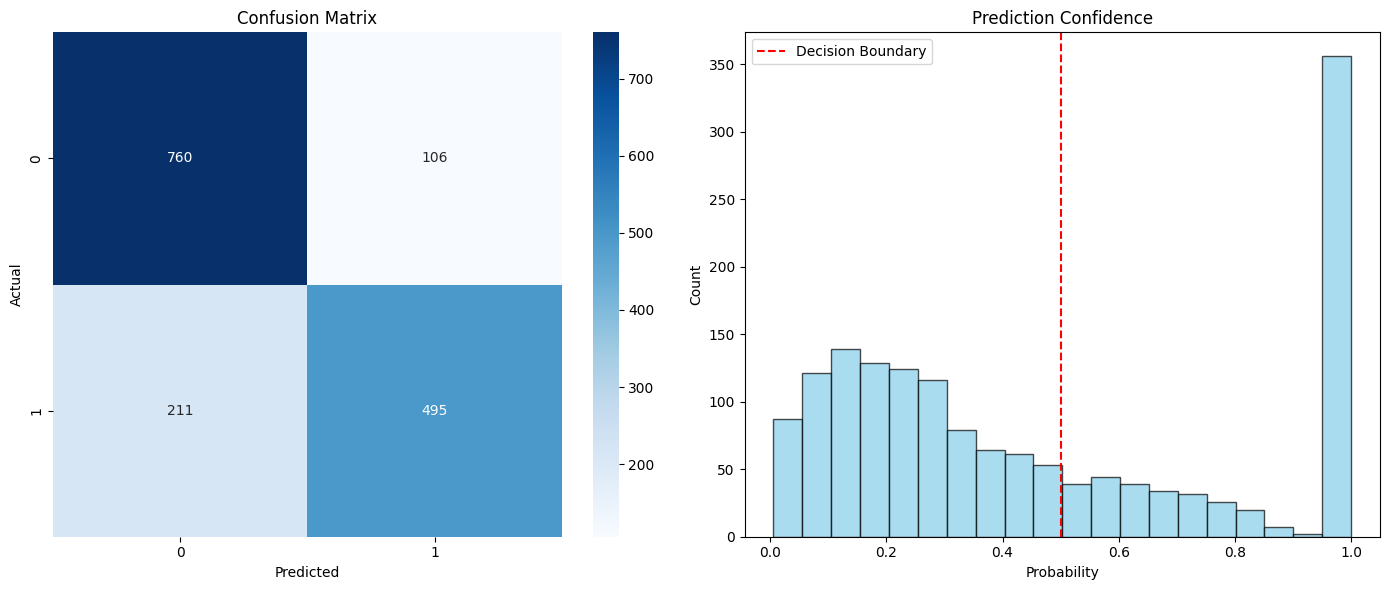

In [4]:
#with redirect_stdout(open('/dev/null', 'w')):
result = run_pipeline(df_quotes)

run_model_error_analysis(result['X_test'], result['y_test'], result['model'])